<a href="https://colab.research.google.com/github/ckmitit/AI-class/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from google.colab import drive

In [4]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
path = '/content/drive/MyDrive/Colab Notebooks/titanic.csv'

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score



* 데이터 불러오기





In [11]:
df = pd.read_csv(path)

# 확인
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


* 전처리

In [12]:
# 필요한 컬럼만 선택
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

# 결측값 처리 (Age)
df['Age'].fillna(df['Age'].mean(), inplace=True)

# 문자열 → 숫자 (Sex)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

/tmp/ipykernel_29280/765874812.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


* x, y 나누기

In [14]:
X = df.drop('Survived', axis=1) # X: 예측에 사용할 데이터
y = df['Survived'] # y: 맞춰야 할 정답 (생존 여부)

* train, test 나누기

In [15]:
# 전체 데이터를 80% 학습, 20% 테스트로 나눔
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

* KNN

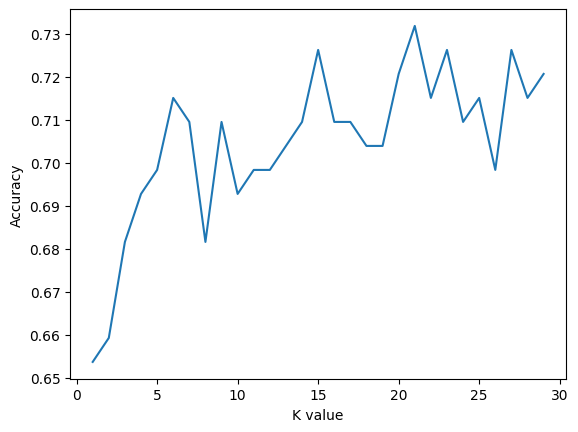

In [16]:
from sklearn import metrics
import matplotlib.pyplot as plt

k_range = range(1, 30) # k값을 1부터 29까지 변화시키며 실험
scores = [] # 각 k값에 대한 정확도 저장 리스트

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k) # KNN 모델 생성 (이웃 개수 = k
    knn.fit(X_train, y_train) # 모델 학습
    y_pred = knn.predict(X_test)    # 테스트 데이터로 예측
    scores.append(metrics.accuracy_score(y_test, y_pred)) # 정확도 계산 후 리스트에 저장

# k값에 따른 정확도 그래프 출력
plt.plot(k_range, scores)
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.show()

* Logistic Regression

In [17]:
lr = LogisticRegression() # Logistic Regression 모델 생성
lr.fit(X_train, y_train) # 모델 학습
y_pred = lr.predict(X_test) # 예측 수행

print("Logistic Accuracy:", accuracy_score(y_test, y_pred)) # 정확도 출력

Logistic Accuracy: 0.7988826815642458


* Decision Tree

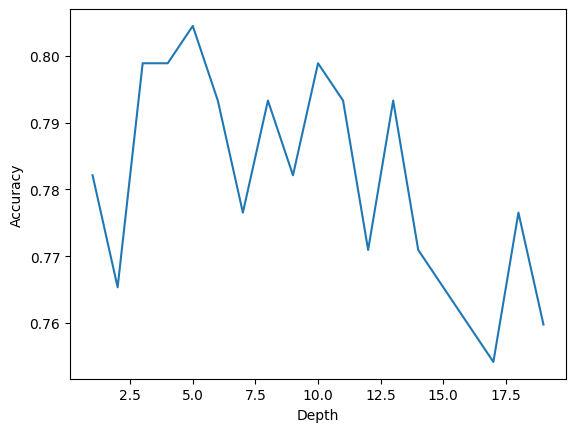

In [18]:
depth_range = range(1, 20) # 트리 깊이를 1~19까지 변경
scores = []

for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d) # Decision Tree 모델 생성 (max_depth 설정)
    dt.fit(X_train, y_train) # 모델 학습
    y_pred = dt.predict(X_test)   # 예측
    scores.append(accuracy_score(y_test, y_pred)) # 정확도 저장

# 깊이에 따른 성능 그래프
plt.plot(depth_range, scores)
plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.show()

* Random Forest

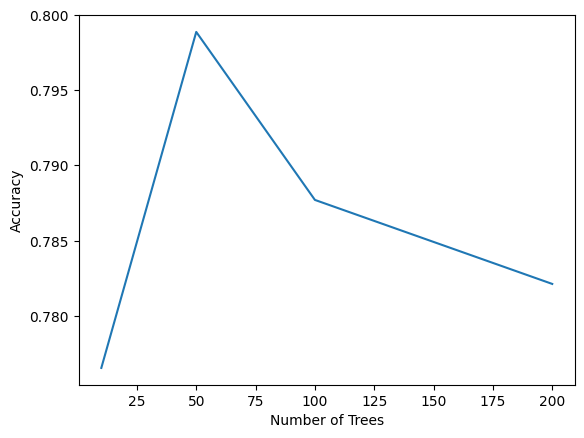

In [19]:
n_range = [10, 50, 100, 200] # 트리 개수 변화
scores = []

for n in n_range:
    rf = RandomForestClassifier(n_estimators=n)  # Random Forest 모델 생성 (트리 개수 설정)
    rf.fit(X_train, y_train)  # 모델 학습
    y_pred = rf.predict(X_test)  # 예측
    scores.append(accuracy_score(y_test, y_pred)) # 정확도 저장

# 트리 개수에 따른 성능 그래프
plt.plot(n_range, scores)
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.show()